In [1]:
import pandas as pd
import os
import re

def files_to_dataframe(directory):
    all_data = pd.DataFrame([])
    for file in os.listdir(directory):
        try:
            df_read = pd.read_csv(directory+file, encoding="utf_8_sig", low_memory=False)
            print(file, df_read.shape)
            df_read['filename'] = str(file)
            # df_read.drop_duplicates(inplace=True)
            ##print(file, df_read.shape)
            all_data = pd.concat([all_data, df_read])
        except Exception as e:
            print(f"Error reading {file}: {e}")
    return all_data

In [2]:
directory_path = 'C:\\programming_projects\\RAG_fine_tune\\RAG_pipeline_ASU_website\\data\\score\\ROGUE\\'
df = files_to_dataframe(directory_path)
print( df.shape)

5_ROGUE_data_part_100_Date_2025_04_21_14_Date_2025_04_22_02.csv (5000, 46)
5_ROGUE_data_part_101_Date_2025_04_21_14_Date_2025_04_22_02.csv (5000, 46)
5_ROGUE_data_part_102_Date_2025_04_21_14_Date_2025_04_22_03.csv (5000, 46)
5_ROGUE_data_part_103_Date_2025_04_21_14_Date_2025_04_22_03.csv (5000, 46)
5_ROGUE_data_part_103_Date_2025_04_21_14_Date_2025_04_22_09.csv (5000, 46)
5_ROGUE_data_part_104_Date_2025_04_21_14_Date_2025_04_22_03.csv (5000, 46)
5_ROGUE_data_part_105_Date_2025_04_21_14_Date_2025_04_22_03.csv (5000, 46)
5_ROGUE_data_part_106_Date_2025_04_21_14_Date_2025_04_22_03.csv (5000, 46)
5_ROGUE_data_part_107_Date_2025_04_21_14_Date_2025_04_22_03.csv (5000, 46)
5_ROGUE_data_part_108_Date_2025_04_21_14_Date_2025_04_22_03.csv (5000, 46)
5_ROGUE_data_part_109_Date_2025_04_21_14_Date_2025_04_22_03.csv (5000, 46)
5_ROGUE_data_part_10_Date_2025_04_21_13_Date_2025_04_21_20.csv (5000, 46)
5_ROGUE_data_part_110_Date_2025_04_21_14_Date_2025_04_22_03.csv (5000, 46)
5_ROGUE_data_part_111_Date

In [3]:
# to_csv('C:\\programming_projects\\RAG_fine_tune\\RAG_pipeline_ASU_website\\data\\score\\')

In [4]:
df.columns

Index(['title', 'url', 'document_type', 'chunked_word_count',
       'orig_word_count', 'context', 'question', 'answer', 'filename',
       'similarity_score', 'NLTK_bleu', 'sacrebleu_bleu', 'Cosine', 'sBURT',
       'ragas_bleu', 'ragas_precision_reference', 'ragas_faith', 'ragas_fact',
       'regas_sem_sim', 'regas_rogue', 'FSCORE_SIM', 'title.1', 'url.1',
       'document_type.1', 'chunked_word_count.1', 'orig_word_count.1',
       'context.1', 'question.1', 'answer.1', 'filename.1',
       'similarity_score.1', 'NLTK_bleu.1', 'sacrebleu_bleu.1', 'Cosine.1',
       'sBURT.1', 'ragas_bleu.1', 'ragas_precision_reference.1',
       'ragas_faith.1', 'ragas_fact.1', 'regas_sem_sim.1', 'regas_rogue.1',
       'FSCORE_SIM.1', 'rouge1', 'rouge2', 'rougeL', 'rougeLsum'],
      dtype='object')

In [5]:
df.describe()

,chunked_word_count,orig_word_count,similarity_score,NLTK_bleu,sacrebleu_bleu,Cosine,sBURT,ragas_bleu,ragas_precision_reference,ragas_faith,...,ragas_precision_reference.1,ragas_faith.1,ragas_fact.1,regas_sem_sim.1,regas_rogue.1,FSCORE_SIM.1,rouge1,rouge2,rougeL,rougeLsum
count,1.996139e+06,1.996139e+06,1.996139e+06,1.996139e+06,1.996139e+06,1.996139e+06,1.996139e+06,1996139.0,1996139.0,1996139.0,...,1996139.0,1996139.0,1996139.0,1996139.0,1996139.0,1.996139e+06,1.996088e+06,1.996088e+06,1.996088e+06,1.996088e+06
mean,3.666987e+02,2.483926e+04,5.441723e+01,7.084471e-03,3.222299e+00,3.322461e-01,7.505063e-01,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.603854e+01,1.451654e-01,6.781085e-02,1.054927e-01,1.054927e-01
std,1.667736e+02,1.610182e+05,1.152853e+01,2.498765e-02,3.549177e+00,1.551877e-01,7.430203e-02,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,9.929306e+00,8.850430e-02,5.738281e-02,6.668915e-02,6.668915e-02
min,1.000000e+00,5.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.745222e-02,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.090000e+02,4.530000e+02,4.800000e+01,9.283879e-07,9.800000e-01,2.402374e-01,7.057557e-01,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.960000e+01,9.009009e-02,2.952030e-02,6.355140e-02,6.355140e-02
50%,5.000000e+02,1.022000e+03,5.400000e+01,2.256287e-05,2.260000e+00,3.468444e-01,7.579034e-01,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.479000e+01,1.245902e-01,5.545287e-02,9.041591e-02,9.041591e-02
75%,5.000000e+02,2.007000e+03,6.100000e+01,1.428533e-03,4.130000e+00,4.407098e-01,8.028294e-01,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.184000e+01,1.818182e-01,9.039548e-02,1.318681e-01,1.318681e-01
max,5.000000e+02,1.387630e+06,1.000000e+02,9.453831e-01,9.418000e+01,9.778707e-01,9.940622e-01,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,9.714000e+01,9.642857e-01,9.624329e-01,9.642857e-01,9.642857e-01


In [6]:
df_dedup = df[['title', 'url', 'document_type', 'chunked_word_count',
              'orig_word_count', 'context', 'question', 'answer', 'filename',
              'similarity_score', 'NLTK_bleu', 'sacrebleu_bleu', 'Cosine', 'sBURT', 'FSCORE_SIM',
              'rouge1', 'rouge2', 'rougeL', 'rougeLsum']].drop_duplicates()

In [7]:
df_dedup.describe()

,chunked_word_count,orig_word_count,similarity_score,NLTK_bleu,sacrebleu_bleu,Cosine,sBURT,FSCORE_SIM,rouge1,rouge2,rougeL,rougeLsum
count,1.996139e+06,1.996139e+06,1.996139e+06,1.996139e+06,1.996139e+06,1.996139e+06,1.996139e+06,1.996139e+06,1.996088e+06,1.996088e+06,1.996088e+06,1.996088e+06
mean,3.666987e+02,2.483926e+04,5.441723e+01,7.084471e-03,3.222299e+00,3.322461e-01,7.505063e-01,2.603854e+01,1.451654e-01,6.781085e-02,1.054927e-01,1.054927e-01
std,1.667736e+02,1.610182e+05,1.152853e+01,2.498765e-02,3.549177e+00,1.551877e-01,7.430203e-02,9.929306e+00,8.850430e-02,5.738281e-02,6.668915e-02,6.668915e-02
min,1.000000e+00,5.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.745222e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.090000e+02,4.530000e+02,4.800000e+01,9.283879e-07,9.800000e-01,2.402374e-01,7.057557e-01,1.960000e+01,9.009009e-02,2.952030e-02,6.355140e-02,6.355140e-02
50%,5.000000e+02,1.022000e+03,5.400000e+01,2.256287e-05,2.260000e+00,3.468444e-01,7.579034e-01,2.479000e+01,1.245902e-01,5.545287e-02,9.041591e-02,9.041591e-02
75%,5.000000e+02,2.007000e+03,6.100000e+01,1.428533e-03,4.130000e+00,4.407098e-01,8.028294e-01,3.184000e+01,1.818182e-01,9.039548e-02,1.318681e-01,1.318681e-01
max,5.000000e+02,1.387630e+06,1.000000e+02,9.453831e-01,9.418000e+01,9.778707e-01,9.940622e-01,9.714000e+01,9.642857e-01,9.624329e-01,9.642857e-01,9.642857e-01


In [8]:
print('df shape:', df.shape)
df.drop_duplicates(inplace=True)
print('drop dups page_text:', df.shape)
df.head()

df shape: (1996139, 46)
drop dups page_text: (1996139, 46)


,title,url,document_type,chunked_word_count,orig_word_count,context,question,answer,filename,similarity_score,...,ragas_precision_reference.1,ragas_faith.1,ragas_fact.1,regas_sem_sim.1,regas_rogue.1,FSCORE_SIM.1,rouge1,rouge2,rougeL,rougeLsum
0,2022 Shaufler Prize recognizing reporting to a...,https://cronkite.asu.edu/news/2022/2022-shaufl...,web page,74,554,consider how well submissions Provide in depth...,What are the key elements that submissions sho...,Submissions should explore and illuminate key ...,5_ROGUE_data_part_100_Date_2025_04_21_14_Date_...,51,...,0.0,0.0,0.0,0.0,0.0,50.55,0.382609,0.123894,0.226087,0.226087
1,2022 Shaufler Prize recognizing reporting to a...,https://cronkite.asu.edu/news/2022/2022-shaufl...,web page,74,554,consider how well submissions Provide in depth...,What are the key elements that submissions sho...,Submissions need to effectively tell stories t...,5_ROGUE_data_part_100_Date_2025_04_21_14_Date_...,53,...,0.0,0.0,0.0,0.0,0.0,46.46,0.242991,0.152381,0.224299,0.224299
2,2022 Shaufler Prize recognizing reporting to a...,https://cronkite.asu.edu/news/2022/2022-shaufl...,web page,74,554,consider how well submissions Provide in depth...,What are the key elements that submissions sho...,Submissions should provide in depth coverage t...,5_ROGUE_data_part_100_Date_2025_04_21_14_Date_...,50,...,0.0,0.0,0.0,0.0,0.0,38.34,0.259259,0.132075,0.240741,0.240741
3,CBS Mornings anchor Gayle King to receive 39th...,https://cronkite.asu.edu/news/2022/cbs-morning...,web page,500,877,Gayle King the award winning co host of CBS Mo...,Can you identify three specific examples of si...,King covered the Trump administration s zero t...,5_ROGUE_data_part_100_Date_2025_04_21_14_Date_...,60,...,0.0,0.0,0.0,0.0,0.0,19.95,0.085502,0.041045,0.066914,0.066914
4,CBS Mornings anchor Gayle King to receive 39th...,https://cronkite.asu.edu/news/2022/cbs-morning...,web page,500,877,Gayle King the award winning co host of CBS Mo...,Can you identify three specific examples of si...,She also reported on the 2016 mass shooting at...,5_ROGUE_data_part_100_Date_2025_04_21_14_Date_...,54,...,0.0,0.0,0.0,0.0,0.0,17.28,0.092764,0.048417,0.066790,0.066790


In [9]:
# df_dedup.to_csv('C:\\programming_projects\\RAG_fine_tune\\RAG_pipeline_ASU_website\\data\\6_scrored.csv')

In [10]:
df_dedup.columns

Index(['title', 'url', 'document_type', 'chunked_word_count',
       'orig_word_count', 'context', 'question', 'answer', 'filename',
       'similarity_score', 'NLTK_bleu', 'sacrebleu_bleu', 'Cosine', 'sBURT',
       'FSCORE_SIM', 'rouge1', 'rouge2', 'rougeL', 'rougeLsum'],
      dtype='object')

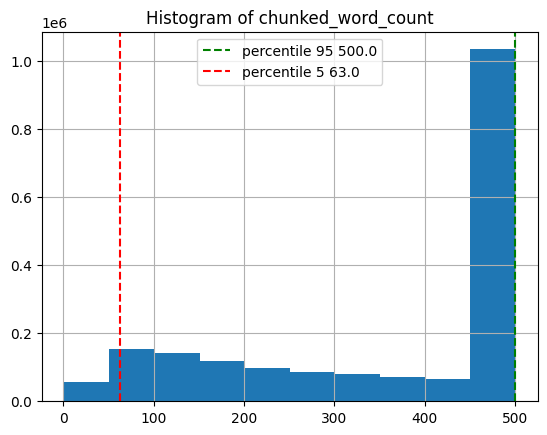

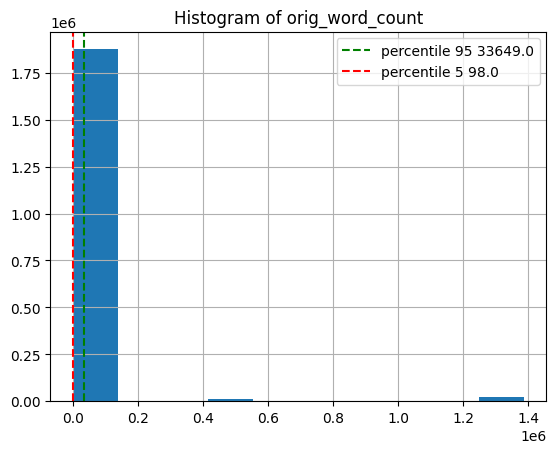

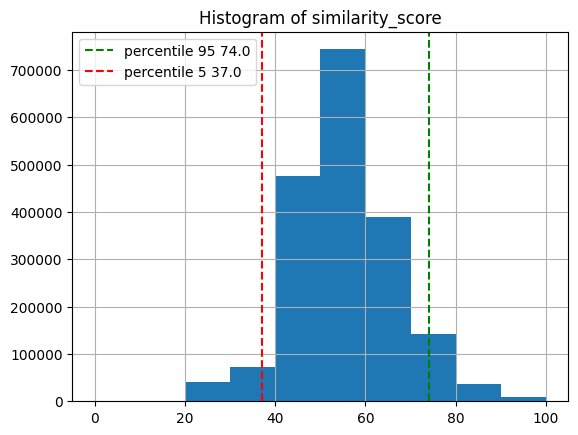

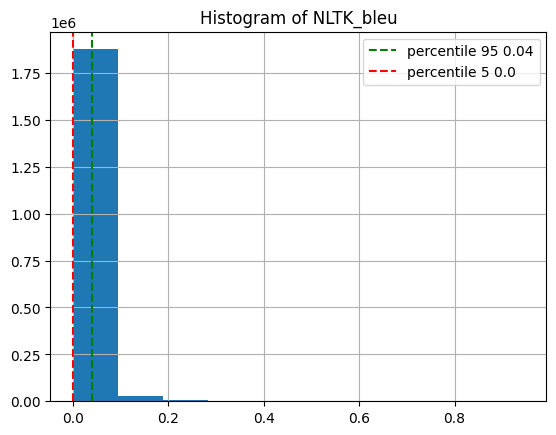

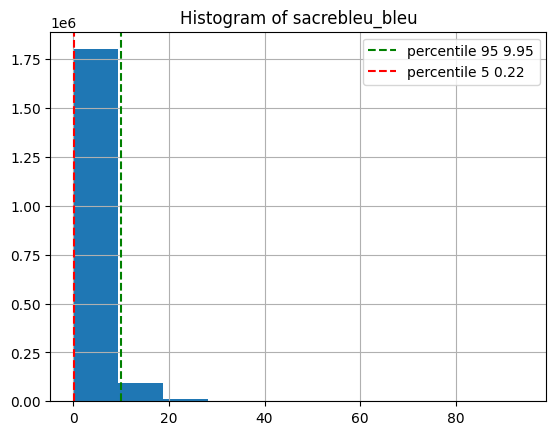

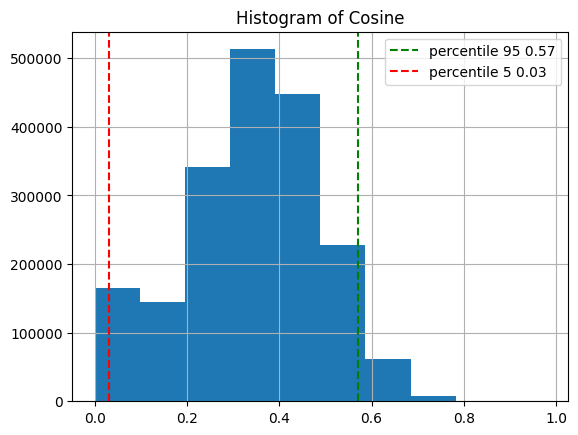

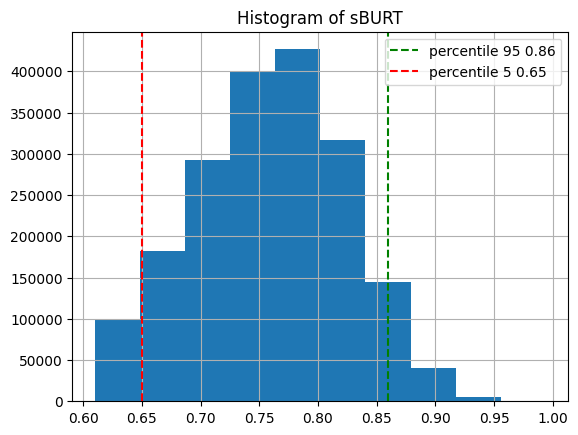

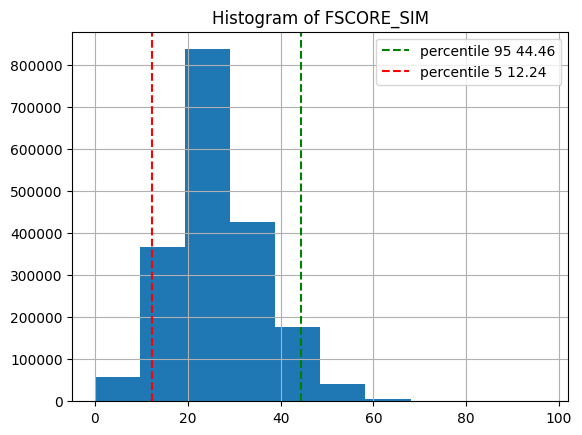

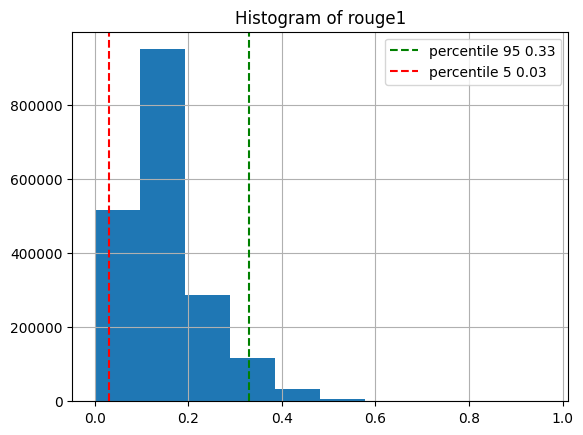

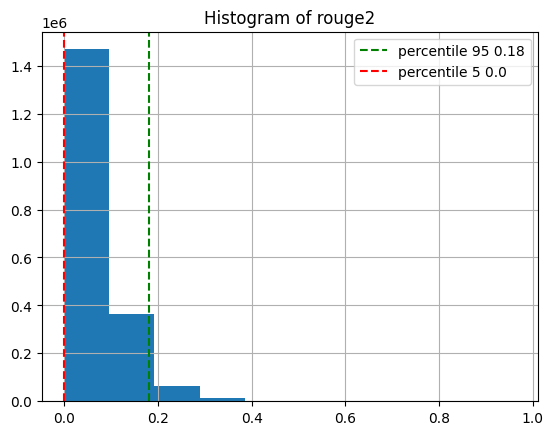

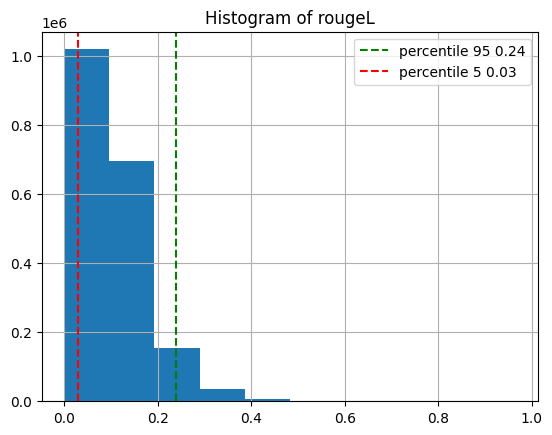

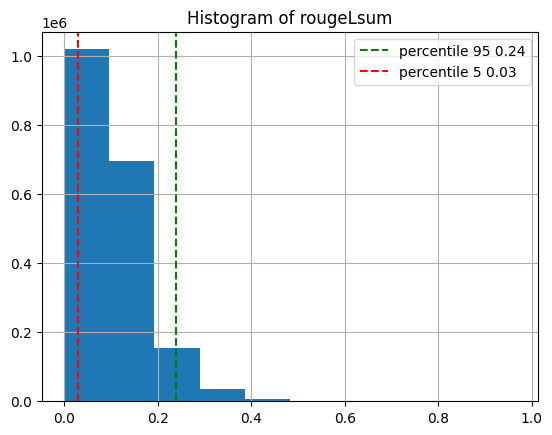

In [11]:
# cutss = df_dedup[df_dedup['sBURT'] > 0.61]
cutss = df_dedup[df_dedup['sBURT'] > 0.61]

import matplotlib 
listy = ['chunked_word_count', 'orig_word_count',
       'similarity_score', 'NLTK_bleu', 'sacrebleu_bleu', 'Cosine', 'sBURT',
       'FSCORE_SIM', 'rouge1', 'rouge2', 'rougeL', 'rougeLsum']
for ii in range(0,12):
    ax = cutss[listy[ii]].hist()
    percentile_90 = round(cutss[listy[ii]].quantile(0.95), 2)
    percentile_05 = round(cutss[listy[ii]].quantile(0.05), 2)
    ax.axvline(x=percentile_90, color='g', linestyle='--', label=f'percentile 95 {percentile_90}')
    ax.axvline(x=percentile_05, color='r', linestyle='--', label=f'percentile 5 {percentile_05}')
    matplotlib.pyplot.title(f'Histogram of {listy[ii]}')
    ax.legend()
    matplotlib.pyplot.show()

In [12]:
import pandas as pd

pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Assuming your DataFrame is named 'df_dedup' and contains the columns:
metrics = ['similarity_score', 'NLTK_bleu', 'sacrebleu_bleu', 'Cosine', 'sBURT', 'FSCORE_SIM', 'rouge1', 'rouge2', 'rougeL', 'rougeLsum']

# 1. Calculate the initial aggregate statistics for all metrics
initial_stats = df_dedup[metrics].describe().reset_index()
initial_stats['metrics_cutoff'] = 'Original'
initial_stats['cutoff_threshold'] = None  # No cutoff applied
all_stats_list = [initial_stats]

print("--- Initial Statistics ---")
print(initial_stats)
print("\n")

row_cat_out = pd.DataFrame([])
row_cat_mean_out = pd.DataFrame([])
# 2. Iterate through each metric to perform the bottom 10% cutoff
for metric_to_cutoff in metrics:
    print(f"--- Analyzing impact of removing bottom 5% based on '{metric_to_cutoff}' ---")

    # Calculate the 10th percentile for the current metric
    cutoff_threshold = df_dedup[metric_to_cutoff].quantile(0.5)
    print(f"Cutoff threshold for {metric_to_cutoff}: {cutoff_threshold:.3f}")

    # Filter the DataFrame to exclude the bottom 10% based on the current metric
    df_filtered = df_dedup[df_dedup[metric_to_cutoff] > (cutoff_threshold)].copy()
    
    col_cat_out = pd.DataFrame([])
    col_cat_mean_out = pd.DataFrame([])
    for cutoff_metric in metrics:
        min_threshold = df_filtered[cutoff_metric].min()
        mean_threshold = df_filtered[cutoff_metric].median()
        initial_mean_threshold = df_dedup[cutoff_metric].median()

        percentile = ((1-(df_dedup[df_dedup[cutoff_metric] >= min_threshold].shape[0] / df_dedup.shape[0]))*100)
        mean_percent = ((mean_threshold - initial_mean_threshold) / initial_mean_threshold) * 100

        ## mean
        col_cat_mean = pd.DataFrame(data={cutoff_metric: [mean_percent]})
        col_cat_mean_out = pd.concat([col_cat_mean_out, col_cat_mean], axis=1)

        ## min
        col_cat = pd.DataFrame(data = {cutoff_metric: [percentile]})
        col_cat_out = pd.concat([col_cat_out, col_cat], axis=1)

    ## min
    row_cat_out = pd.concat([row_cat_out, col_cat_out], axis=0)

    ## mean
    row_cat_mean_out = pd.concat([row_cat_mean_out, col_cat_mean_out], axis=0)

row_cat_out['metrics'] = metrics
row_cat_mean_out['metrics'] = metrics
row_cat_out

--- Initial Statistics ---
   index  similarity_score   NLTK_bleu  sacrebleu_bleu      Cosine  \
0  count       1996139.000 1996139.000     1996139.000 1996139.000   
1   mean            54.417       0.007           3.222       0.332   
2    std            11.529       0.025           3.549       0.155   
3    min             0.000       0.000           0.000       0.000   
4    25%            48.000       0.000           0.980       0.240   
5    50%            54.000       0.000           2.260       0.347   
6    75%            61.000       0.001           4.130       0.441   
7    max           100.000       0.945          94.180       0.978   

        sBURT  FSCORE_SIM      rouge1      rouge2      rougeL   rougeLsum  \
0 1996139.000 1996139.000 1996088.000 1996088.000 1996088.000 1996088.000   
1       0.751      26.039       0.145       0.068       0.105       0.105   
2       0.074       9.929       0.089       0.057       0.067       0.067   
3       0.097       0.000       0.

,similarity_score,NLTK_bleu,sacrebleu_bleu,Cosine,sBURT,FSCORE_SIM,rouge1,rouge2,rougeL,rougeLsum,metrics
0,53.855,0.000,0.000,0.000,0.000,0.084,0.003,0.003,0.003,0.003,similarity_score
0,0.004,50.000,0.000,0.000,0.000,0.022,0.003,0.003,0.003,0.003,NLTK_bleu
0,0.150,0.000,50.112,0.000,0.000,0.199,4.281,0.003,5.109,5.109,sacrebleu_bleu
0,0.059,0.000,0.000,50.000,0.000,0.067,4.423,0.003,4.670,4.670,Cosine
0,0.000,0.000,0.000,0.000,50.000,0.000,0.003,0.003,0.003,0.003,sBURT
0,0.566,0.000,0.000,0.000,0.000,50.014,0.003,0.003,0.003,0.003,FSCORE_SIM
0,0.054,0.000,0.000,0.000,0.000,0.067,50.004,0.003,6.564,6.564,rouge1
0,0.069,0.000,0.000,0.000,0.000,0.067,10.944,50.020,6.914,6.914,rouge2
0,0.054,0.000,0.000,0.000,0.000,0.067,25.242,0.003,50.023,50.023,rougeL
0,0.054,0.000,0.000,0.000,0.000,0.067,25.242,0.003,50.023,50.023,rougeLsum


In [13]:
row_cat_out

,similarity_score,NLTK_bleu,sacrebleu_bleu,Cosine,sBURT,FSCORE_SIM,rouge1,rouge2,rougeL,rougeLsum,metrics
0,53.855,0.000,0.000,0.000,0.000,0.084,0.003,0.003,0.003,0.003,similarity_score
0,0.004,50.000,0.000,0.000,0.000,0.022,0.003,0.003,0.003,0.003,NLTK_bleu
0,0.150,0.000,50.112,0.000,0.000,0.199,4.281,0.003,5.109,5.109,sacrebleu_bleu
0,0.059,0.000,0.000,50.000,0.000,0.067,4.423,0.003,4.670,4.670,Cosine
0,0.000,0.000,0.000,0.000,50.000,0.000,0.003,0.003,0.003,0.003,sBURT
0,0.566,0.000,0.000,0.000,0.000,50.014,0.003,0.003,0.003,0.003,FSCORE_SIM
0,0.054,0.000,0.000,0.000,0.000,0.067,50.004,0.003,6.564,6.564,rouge1
0,0.069,0.000,0.000,0.000,0.000,0.067,10.944,50.020,6.914,6.914,rouge2
0,0.054,0.000,0.000,0.000,0.000,0.067,25.242,0.003,50.023,50.023,rougeL
0,0.054,0.000,0.000,0.000,0.000,0.067,25.242,0.003,50.023,50.023,rougeLsum


In [14]:
row_cat_mean_out

,similarity_score,NLTK_bleu,sacrebleu_bleu,Cosine,sBURT,FSCORE_SIM,rouge1,rouge2,rougeL,rougeLsum,metrics
0,14.815,26.054,53.540,17.790,2.064,8.511,10.708,41.929,18.289,18.289,similarity_score
0,0.000,6231.765,68.584,6.268,3.543,28.318,45.933,53.475,45.049,45.049,NLTK_bleu
0,9.259,1454.856,83.186,16.936,3.597,23.397,34.472,61.493,39.412,39.412,sacrebleu_bleu
0,7.407,80.326,42.920,27.063,2.436,9.964,14.243,34.829,17.058,17.058,Cosine
0,3.704,904.227,44.690,11.210,5.928,17.789,27.571,35.371,27.309,27.309,sBURT
0,3.704,3861.377,76.549,13.363,3.991,28.439,43.920,58.784,43.481,43.481,FSCORE_SIM
0,3.704,4646.751,78.761,14.568,4.183,28.318,45.933,61.493,45.846,45.846,rouge1
0,9.259,1581.390,82.301,18.123,3.701,24.002,36.447,63.050,41.020,41.020,rouge2
0,7.407,4455.579,81.416,15.199,4.095,27.914,45.678,62.462,45.846,45.846,rougeL
0,7.407,4455.579,81.416,15.199,4.095,27.914,45.678,62.462,45.846,45.846,rougeLsum


In [28]:
golden = df_dedup[df_dedup['chunked_word_count'] > 50]
golden = golden[golden['FSCORE_SIM'] > 22]
golden = golden[golden['rouge1'] > 0.11]
golden.shape
golden.to_csv('C:\\programming_projects\\RAG_fine_tune\\RAG_pipeline_ASU_website\\data\\6_golden.csv')